# **Imports**

In [1]:

import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# **Clean and Combine Data**

In [2]:
MATURITIES = {
    '1M':  'DGS1MO.csv',
    '3M':  'DGS3MO.csv',
    '6M':  'DGS6MO.csv',
    '1Y':  'DGS1.csv',
    '2Y':  'DGS2.csv',
    '5Y':  'DGS5.csv',
    '7Y':  'DGS7.csv',
    '10Y': 'DGS10.csv',
    '20Y': 'DGS20.csv',
    '30Y': 'DGS30.csv'
}

# Loads the maturity respective FRED CSV
def load_csv(filepath, col_name):
    file = pd.read_csv(filepath, parse_dates=['observation_date'], index_col='observation_date')
    file.columns = [col_name]
    file[col_name] = pd.to_numeric(file[col_name], errors='coerce')
    return file


def load_all_yields(maturity_dict):
    full_dataset = []
    for label, filename in maturity_dict.items():
        individual_data = load_csv(filename, label)
        full_dataset.append(individual_data)
    combined_data = pd.concat(full_dataset, axis=1, join='outer')
    combined_data.index.name = 'Date'
    combined_data.sort_index(inplace=True)
    return combined_data


raw_data = load_all_yields(MATURITIES)

#print("Percent missing per column")
#print(raw_data.isnull().sum() / len(raw_data) * 100)

def clean_yields(data, max_consec_fill=5):
    cleaned = data.ffill(limit=max_consec_fill)
    cleaned.dropna(how='all', inplace=True)
    threshold = len(cleaned.columns) // 2 # half the columns are NaN
    cleaned.dropna(thresh=threshold, inplace=True)
    return cleaned

yields = clean_yields(raw_data)
yields_only = yields.dropna()

# **Visualizations**

## *Yield Over Time*

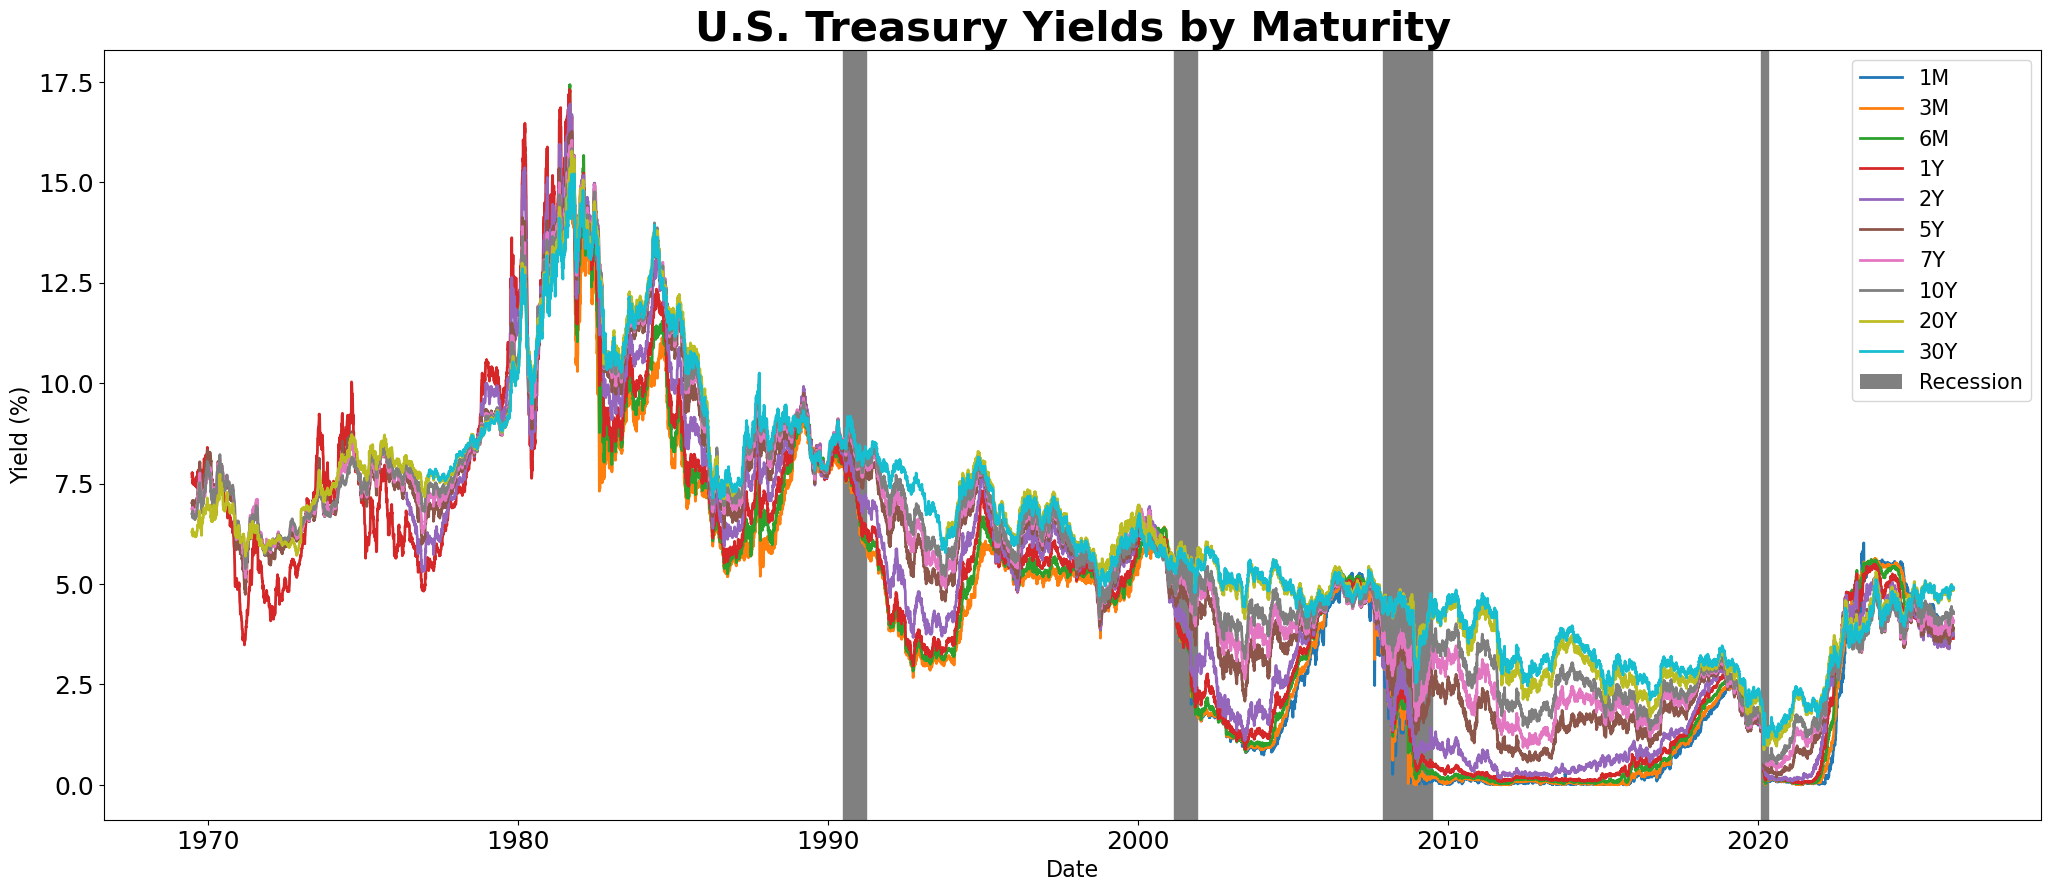

In [3]:
def yields_over_time(data):
    # Wikipedia list of recessions that fall in the date range of dataset
    recessions = [
        ('1990-07-01', '1991-03-31'),
        ('2001-03-01', '2001-11-30'),
        ('2007-12-01', '2009-06-30'),
        ('2020-02-01', '2020-04-30'),
    ]
    fig, ax = plt.subplots(figsize=(25, 10))
    
    for col in data.columns:
        ax.plot(data.index, data[col], linewidth=2, label=col)
    for (start, end) in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='gray', label='_nolegend_')

    ax.tick_params(axis='both', labelsize=18)
    recession_label = Patch(facecolor='gray', label='Recession')
    ax.set_title('U.S. Treasury Yields by Maturity', fontsize=30, fontweight='bold')
    ax.set_xlabel('Date', fontsize=16)
    ax.set_ylabel('Yield (%)', fontsize=16)
    ax.legend(handles=[*ax.lines, recession_label], loc='upper right', ncol=1, fontsize=15)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.savefig('yields_over_time.png', dpi=150)
    plt.show()

yields_over_time(yields)

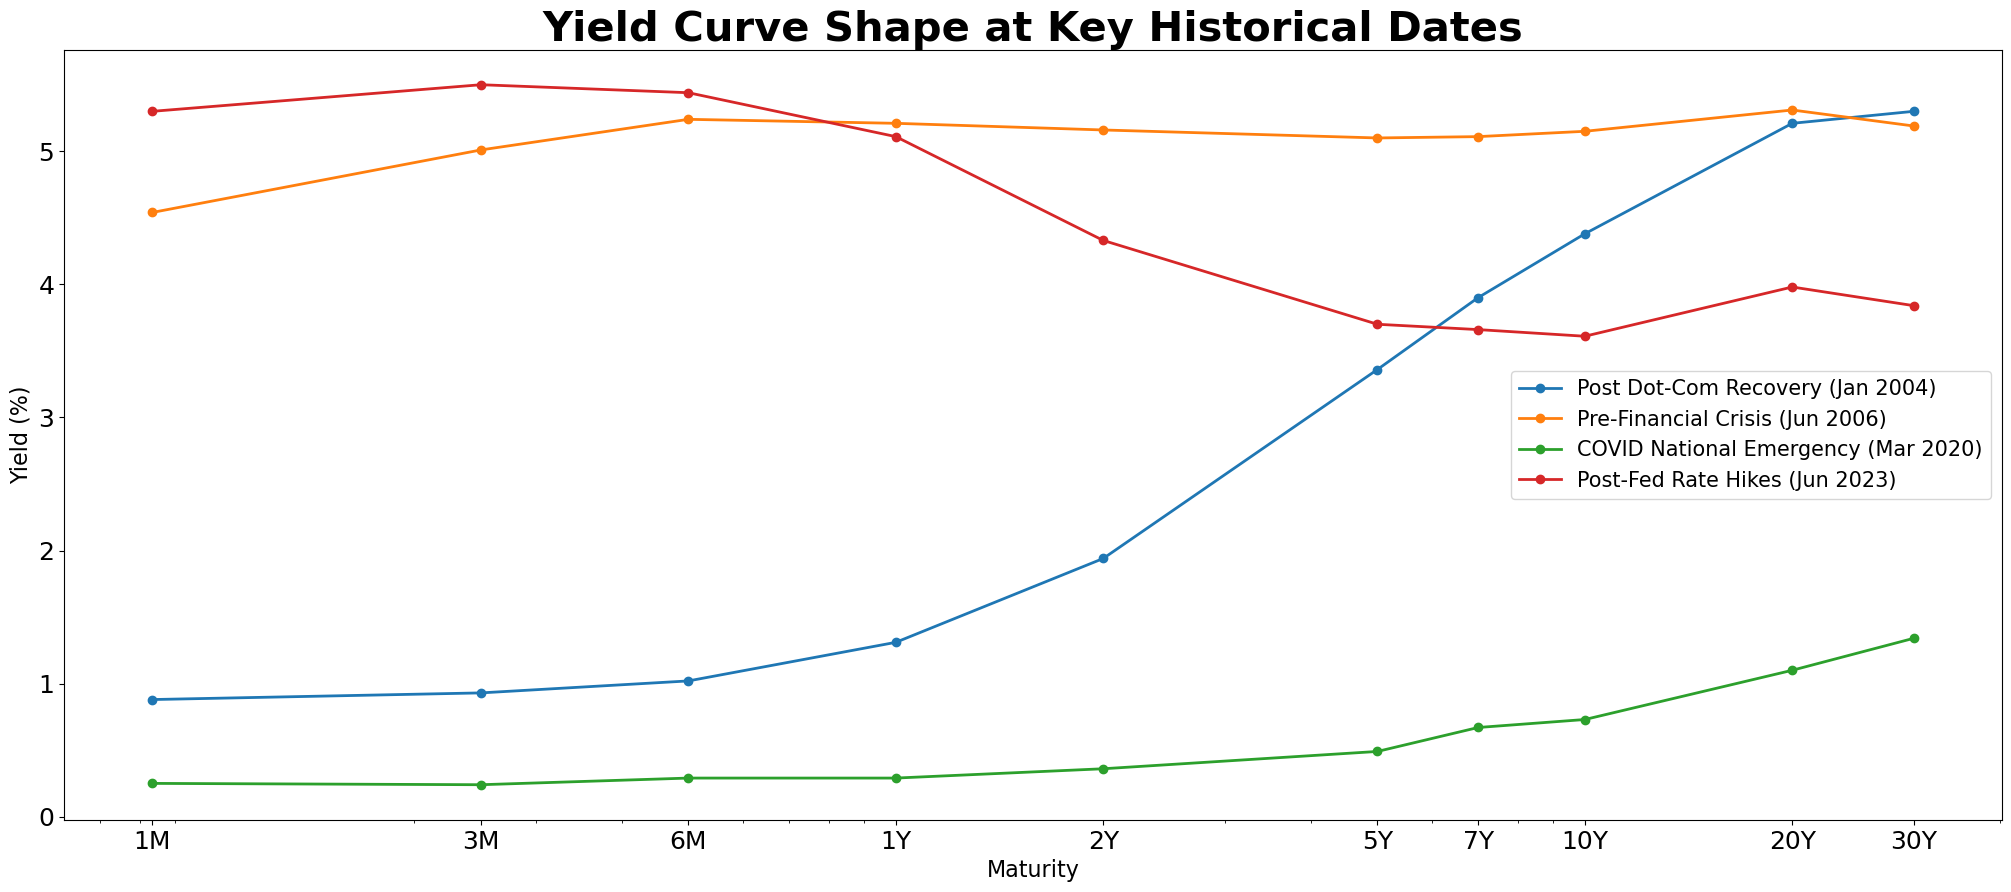

In [4]:
MATURITY_YEARS = [1/12, 3/12, 6/12, 1, 2, 5, 7, 10, 20, 30]

def plot_curve_snapshots(data, dates, labels):
    fig, ax = plt.subplots(figsize=(25, 10))
    
    for i, (date, label) in enumerate(zip(dates, labels)):
        # Gives the nearest date in yields so it doesn't crash on weekends
        nearest = data.index[data.index.get_indexer([pd.Timestamp(date)], method='nearest')[0]]
        row = data.loc[nearest]
        ax.plot(MATURITY_YEARS, row.values, marker='o', linewidth=2, label=f"{label} ({nearest.strftime('%b %Y')})")
    
    ax.set_xscale('log')
    ax.set_xticks(MATURITY_YEARS)
    ax.tick_params(axis='both', labelsize=18)
    ax.set_xticklabels(['1M','3M','6M','1Y','2Y','5Y','7Y','10Y','20Y','30Y'])
    ax.set_title('Yield Curve Shape at Key Historical Dates', fontsize=30, fontweight='bold')
    ax.set_xlabel('Maturity', fontsize=16)
    ax.set_ylabel('Yield (%)', fontsize=16)
    ax.legend(fontsize=15)
    plt.savefig('curve_history.png', dpi=150)
    plt.show()

# I picked these dates because they each represent a really different 
# economic environment, so you can see how drastically the curve shape changes.

# 2004-01-02: After the dot-com crash and 9/11, the Fed slashed interest rates 
#             to basically nothing (1%) to rescue the economy. Since short term 
#             rates were so low but long term rates were still normal, the curve 
#             slopes steeply upward, which is a sign of a good future economy

# 2006-06-30: Between 2004 and 2006 the Fed raised rates 17 times in a row to cool 
#           the economy down. This pushed short term yields way up until they 
#           almost caught up to long term yields. Historically, the curve being
#           almost flat has been a warning sign for recession

# 2020-03-15: The day COVID was declared a national emergency, the Fed cut rates 
#           to 0%. Short rates crashed to almost nothing while long rates stayed 
#           elevated. Different from 2006, COVID was more of a shock for the economy

# 2023-06-01: To fight the worst inflation in 40 years post COVID, the Fed raised 
#           rates 11 times. Short term yields shot up so fast they blew past 
#           long term yields, flipping the curve upside down, an inversion, which
#           historically has caused recessions
snapshot_dates  = ['2004-01-02', '2006-06-30', '2020-03-15', '2023-06-01']
snapshot_labels = ['Post Dot-Com Recovery', 'Pre-Financial Crisis', 'COVID National Emergency', 'Post-Fed Rate Hikes']

plot_curve_snapshots(yields_only, snapshot_dates, snapshot_labels)

## *Short vs Long Term Yields Over Time*

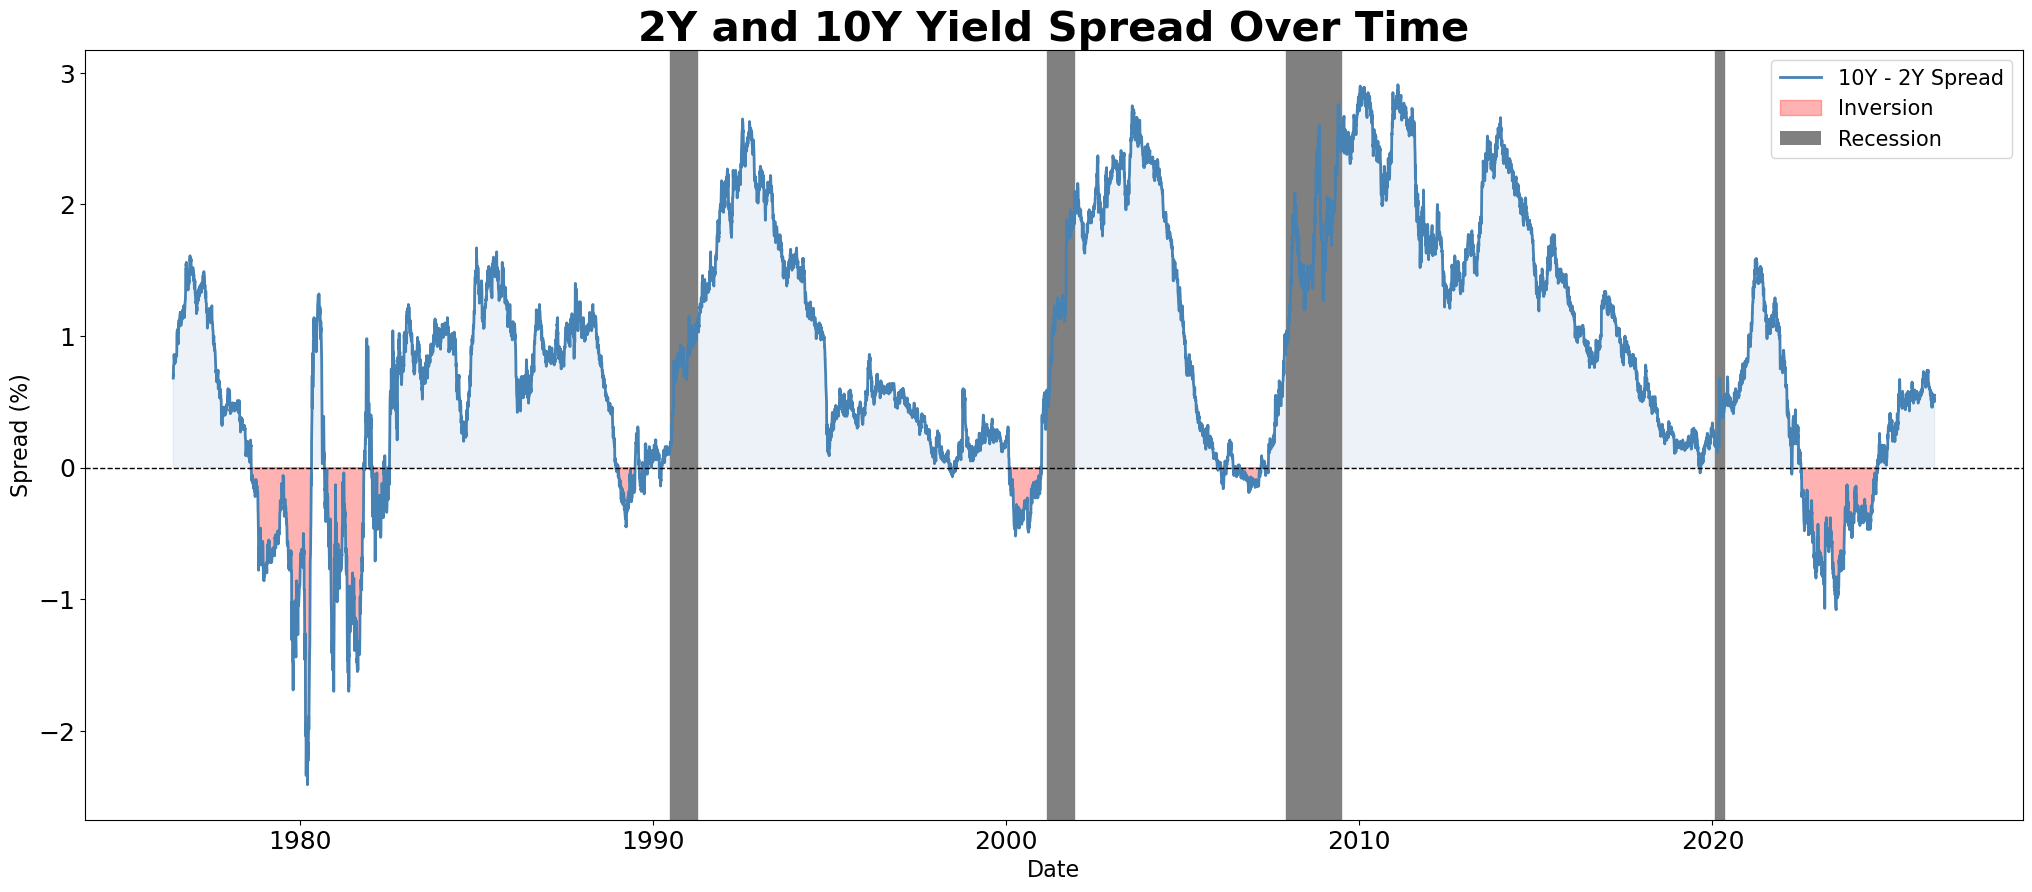

In [5]:
def shortvslongovertime(data):
    recessions = [
        ('1990-07-01', '1991-03-31'),
        ('2001-03-01', '2001-11-30'),
        ('2007-12-01', '2009-06-30'),
        ('2020-02-01', '2020-04-30'),
    ]
    
    spread = data['10Y'] - data['2Y']
    spread = spread.dropna()
    
    fig, ax = plt.subplots(figsize=(25, 10))
    
    ax.plot(spread.index, spread.values, linewidth=2, color='steelblue', label='10Y - 2Y Spread')
    ax.fill_between(spread.index, spread.values, 0, where=(spread.values < 0), color='red', alpha=0.3, label='Inversion')
    ax.fill_between(spread.index, spread.values, 0, where=(spread.values >= 0), color='steelblue', alpha=0.1)
    ax.axhline(0, color='black', linewidth=1, linestyle='--')
    
    for start, end in recessions:
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=1, color='gray')
    
    ax.set_title('2Y and 10Y Yield Spread Over Time', fontsize=30, fontweight='bold')
    ax.set_xlabel('Date', fontsize=16)
    ax.set_ylabel('Spread (%)', fontsize=16)
    ax.tick_params(axis='both', labelsize=18)
    recession_label = Patch(facecolor='gray', label='Recession')
    ax.legend(handles=[*ax.get_legend_handles_labels()[0], recession_label], labels=[*ax.get_legend_handles_labels()[1], 'Recession'], fontsize=15)
    plt.savefig('shortlongspreadtime.png', dpi=150)
    plt.show()
    
    return spread


shortvslongspread = shortvslongovertime(yields)

## *Correlation Map Between Different Yields*

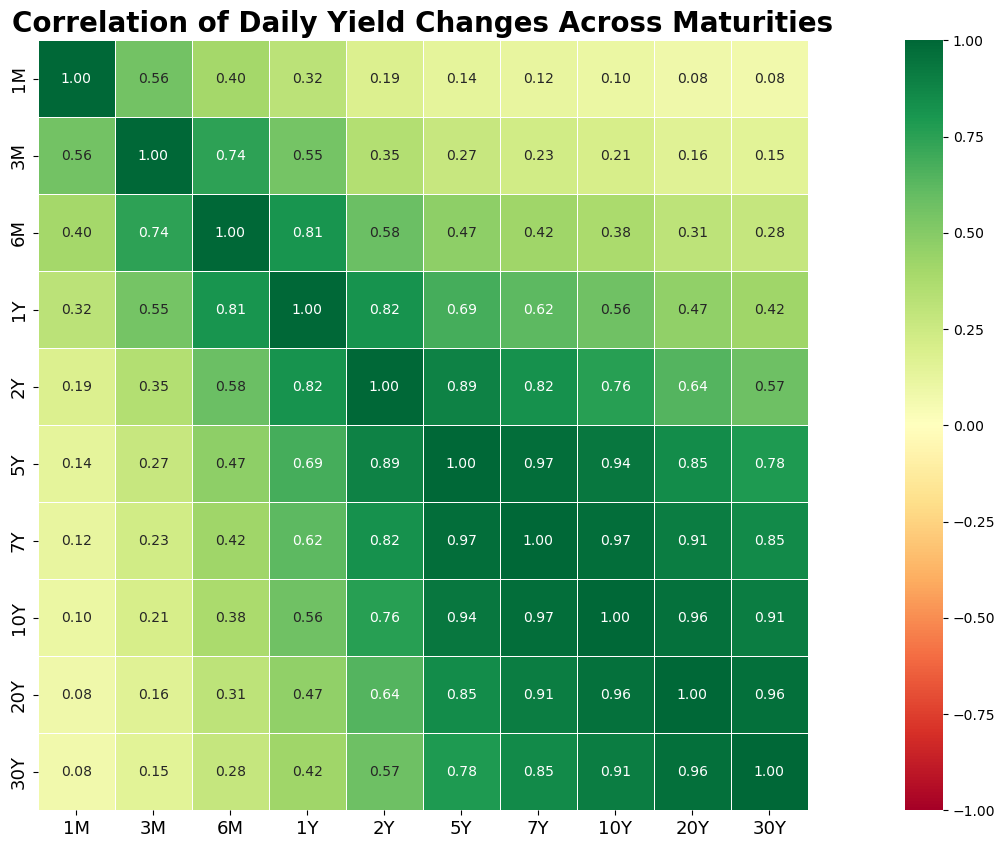

In [6]:
def correlation_map(data):
    correlations = data.diff().dropna().corr()
    
    fig, ax = plt.subplots(figsize=(25, 10))
    sns.heatmap(correlations, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1, center=0, ax=ax, linewidths=0.5, square=True)
    ax.set_title('Correlation of Daily Yield Changes Across Maturities', fontsize=20, fontweight='bold')
    ax.tick_params(axis='both', labelsize=13)
    plt.savefig('correlation_map.png', dpi=150)
    plt.show()


correlation_map(yields_only)

## *PCA Analysis*

In [7]:
def fit_pca(data, n_components=5):
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data.values)
    
    pca = PCA(n_components=n_components)
    scores = pca.fit_transform(scaled)
    
    scores_df = pd.DataFrame(
        scores,
        index=data.index,
        columns=[f'PC{i+1}' for i in range(n_components)]
    )
    
    return scaler, pca, scores_df


scaler, pca, pc_scores = fit_pca(yields_only)

for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var*100:.2f}%")

PC1: 83.72%
PC2: 15.05%
PC3: 0.98%
PC4: 0.14%
PC5: 0.05%


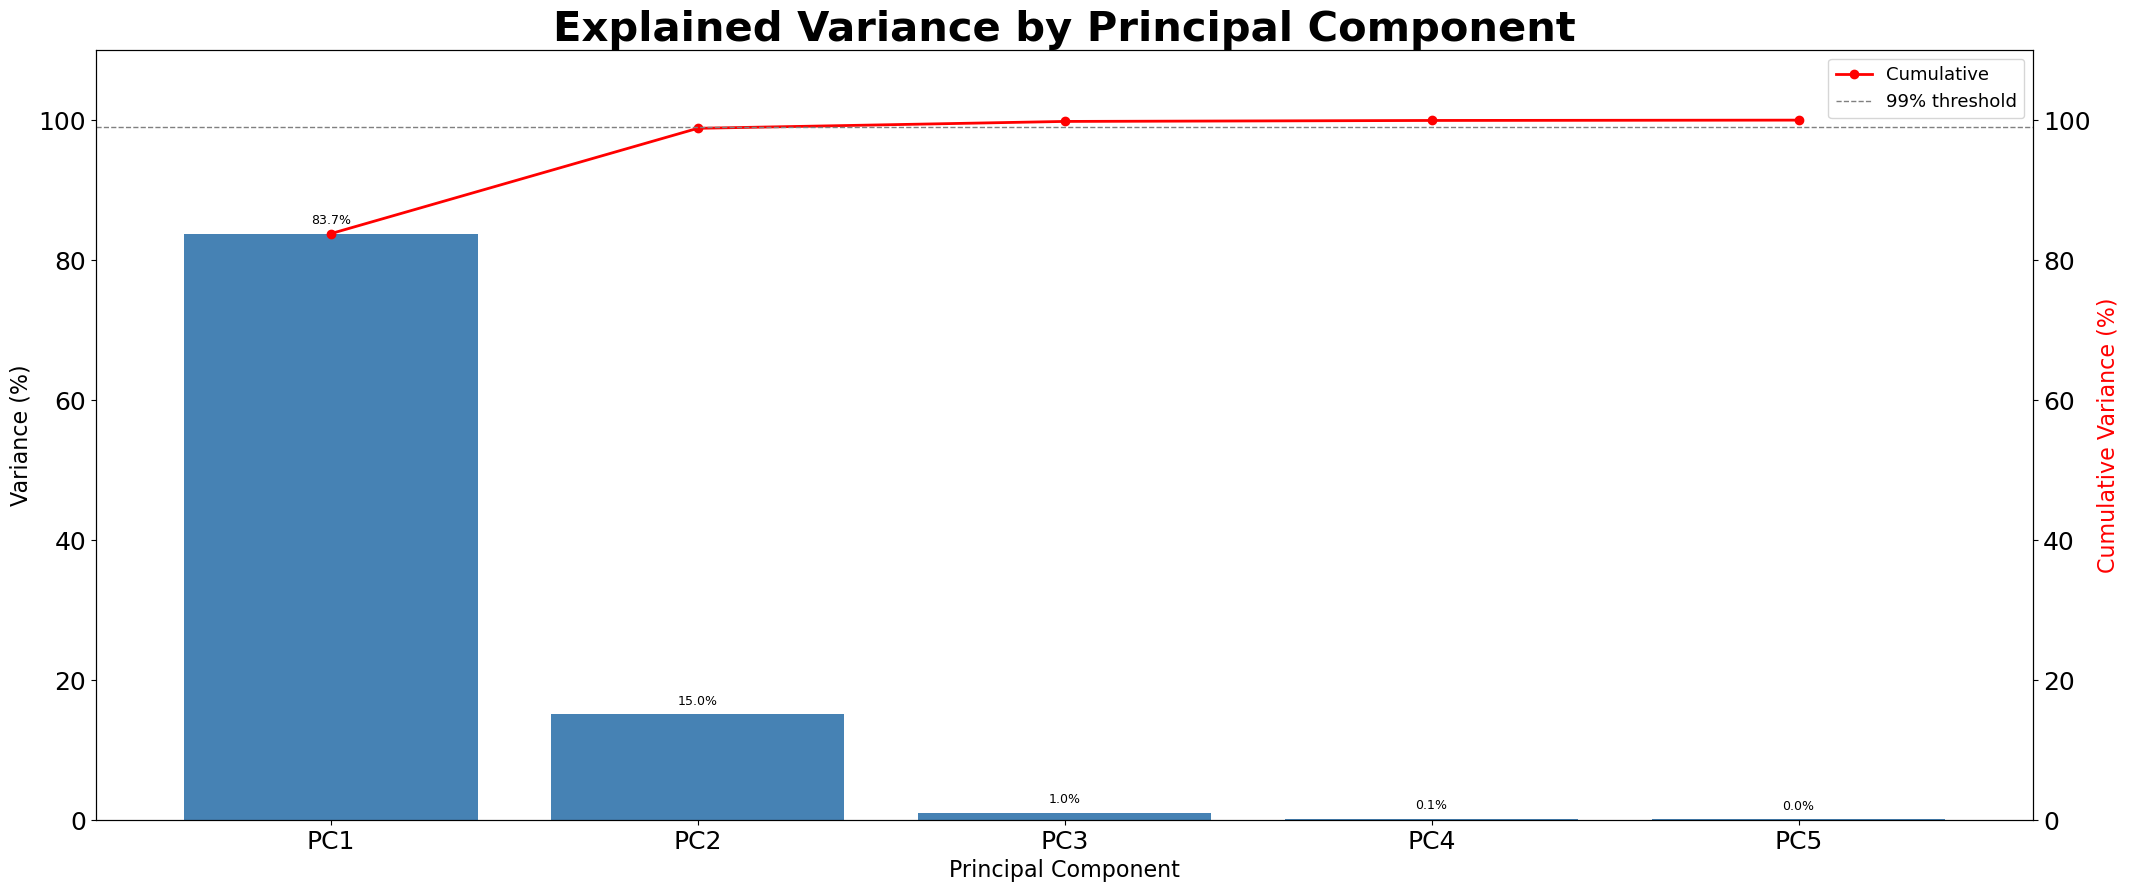

In [8]:
def explained_variance(pca):
    n = len(pca.explained_variance_ratio_)
    labels = [f'PC{i+1}' for i in range(n)]
    individual = pca.explained_variance_ratio_ * 100
    cumulative = np.cumsum(individual)
    
    fig, ax1 = plt.subplots(figsize=(25, 10))
    
    bars = ax1.bar(labels, individual, color='steelblue')
    ax1.set_ylabel('Variance (%)', fontsize=16)
    ax1.set_ylim(0, 110)
    
    ax2 = ax1.twinx()
    ax2.plot(labels, cumulative, color='red', marker='o', linewidth=2, label='Cumulative')
    ax2.axhline(99, color='gray', linestyle='--', linewidth=1.0, label='99% threshold')
    ax2.legend(loc='upper right', fontsize=13)
    ax1.tick_params(axis='both', labelsize=18)
    ax2.tick_params(axis='both', labelsize=18)
    ax2.set_ylabel('Cumulative Variance (%)', color='red', fontsize=16)
    ax2.set_ylim(0, 110)
    
    for bar, val in zip(bars, individual):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
    
    ax1.set_title('Explained Variance by Principal Component', fontsize=30, fontweight='bold')
    ax1.set_xlabel('Principal Component', fontsize=16)
    plt.savefig('explained_variance.png', dpi=150)
    plt.show()


explained_variance(pca)

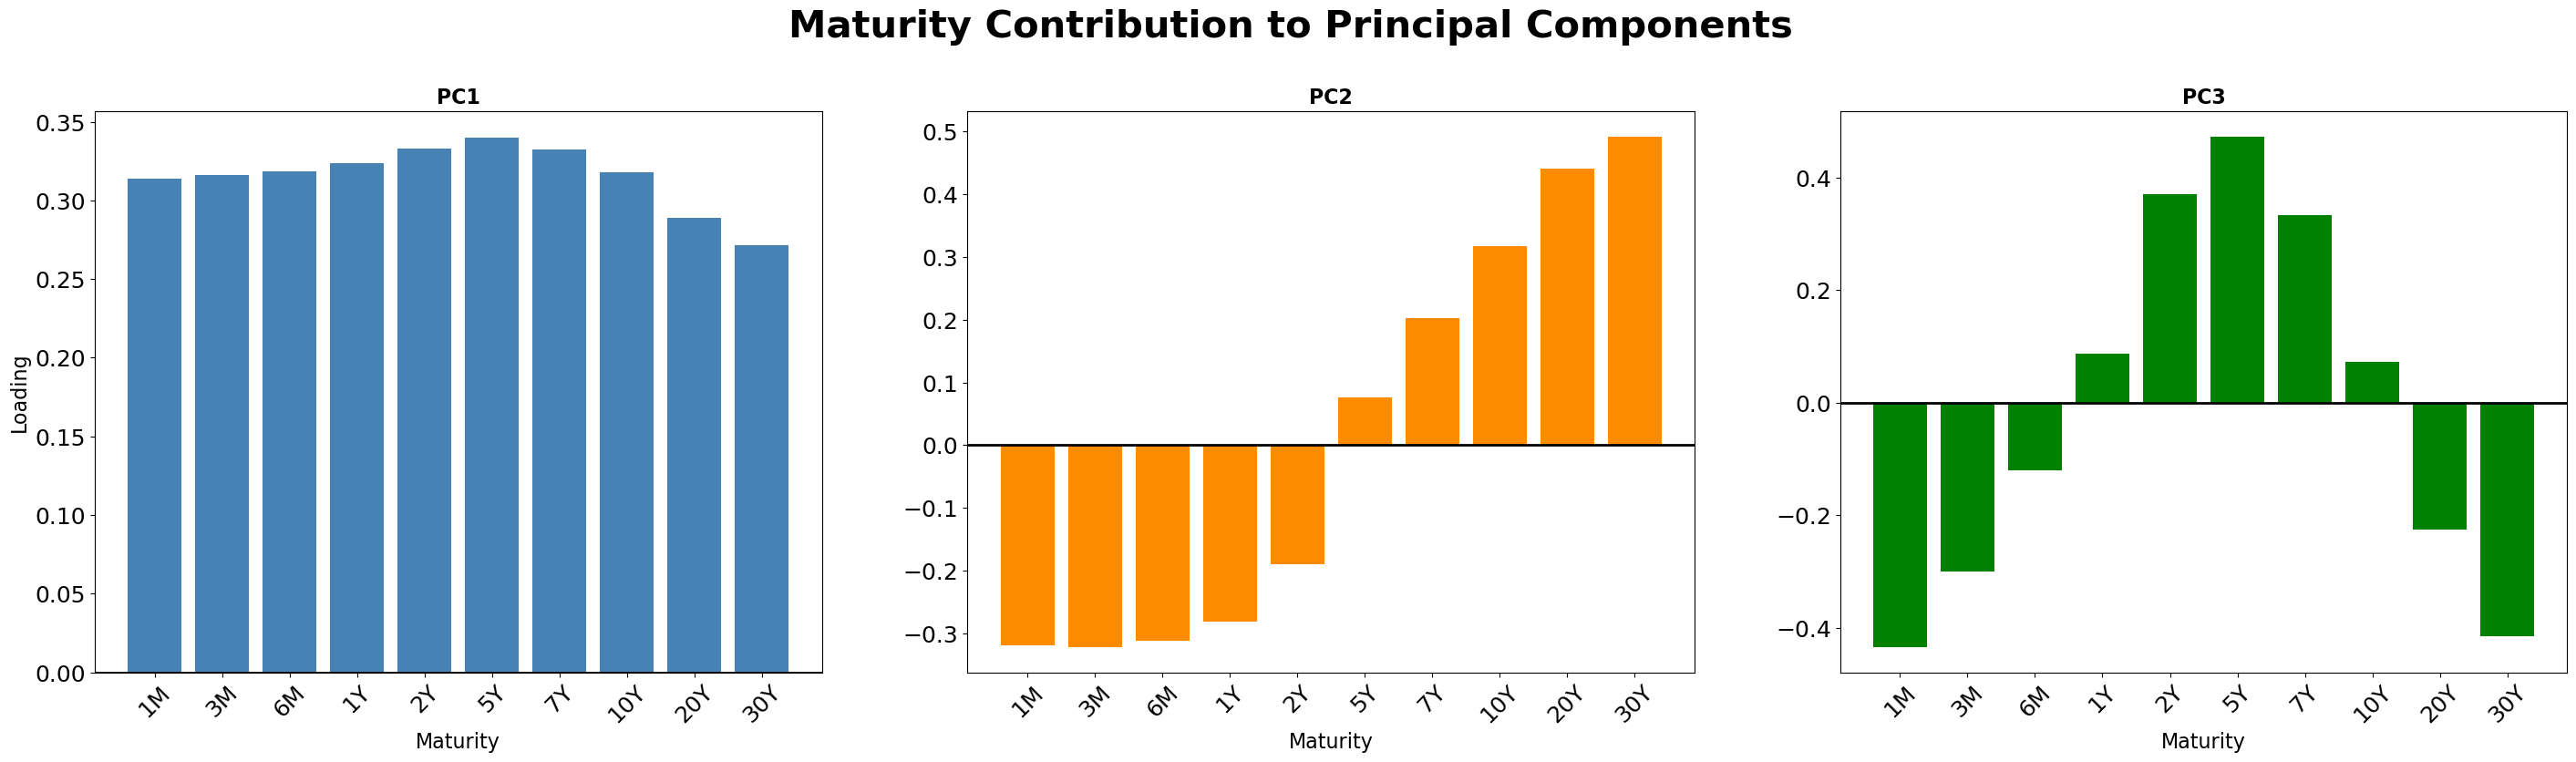

In [9]:
def pca_loadings(pca, columns):
    factor_names = ['PC1', 'PC2', 'PC3']
    colors_pc = ['steelblue', 'darkorange', 'green']
    
    fig, axes = plt.subplots(1, 3, figsize=(35, 8))
    
    for i, (ax, name, color) in enumerate(zip(axes, factor_names, colors_pc)):
        loadings = pca.components_[i]
        ax.bar(columns, loadings, color=color)
        ax.axhline(0, color='black', linewidth=2)
        ax.set_title(name, fontsize=16, fontweight='bold')
        ax.set_xlabel('Maturity', fontsize=16)
        ax.set_ylabel('Loading' if i == 0 else '', fontsize=16)
        ax.tick_params(axis='x', rotation=45)
        ax.tick_params(axis='both', labelsize=18)
    
    fig.suptitle('Maturity Contribution to Principal Components', fontsize=30, fontweight='bold', y=1.02)
    plt.savefig('maturity_contrib_pca.png', dpi=150)
    plt.show()


pca_loadings(pca, yields_only.columns.tolist())

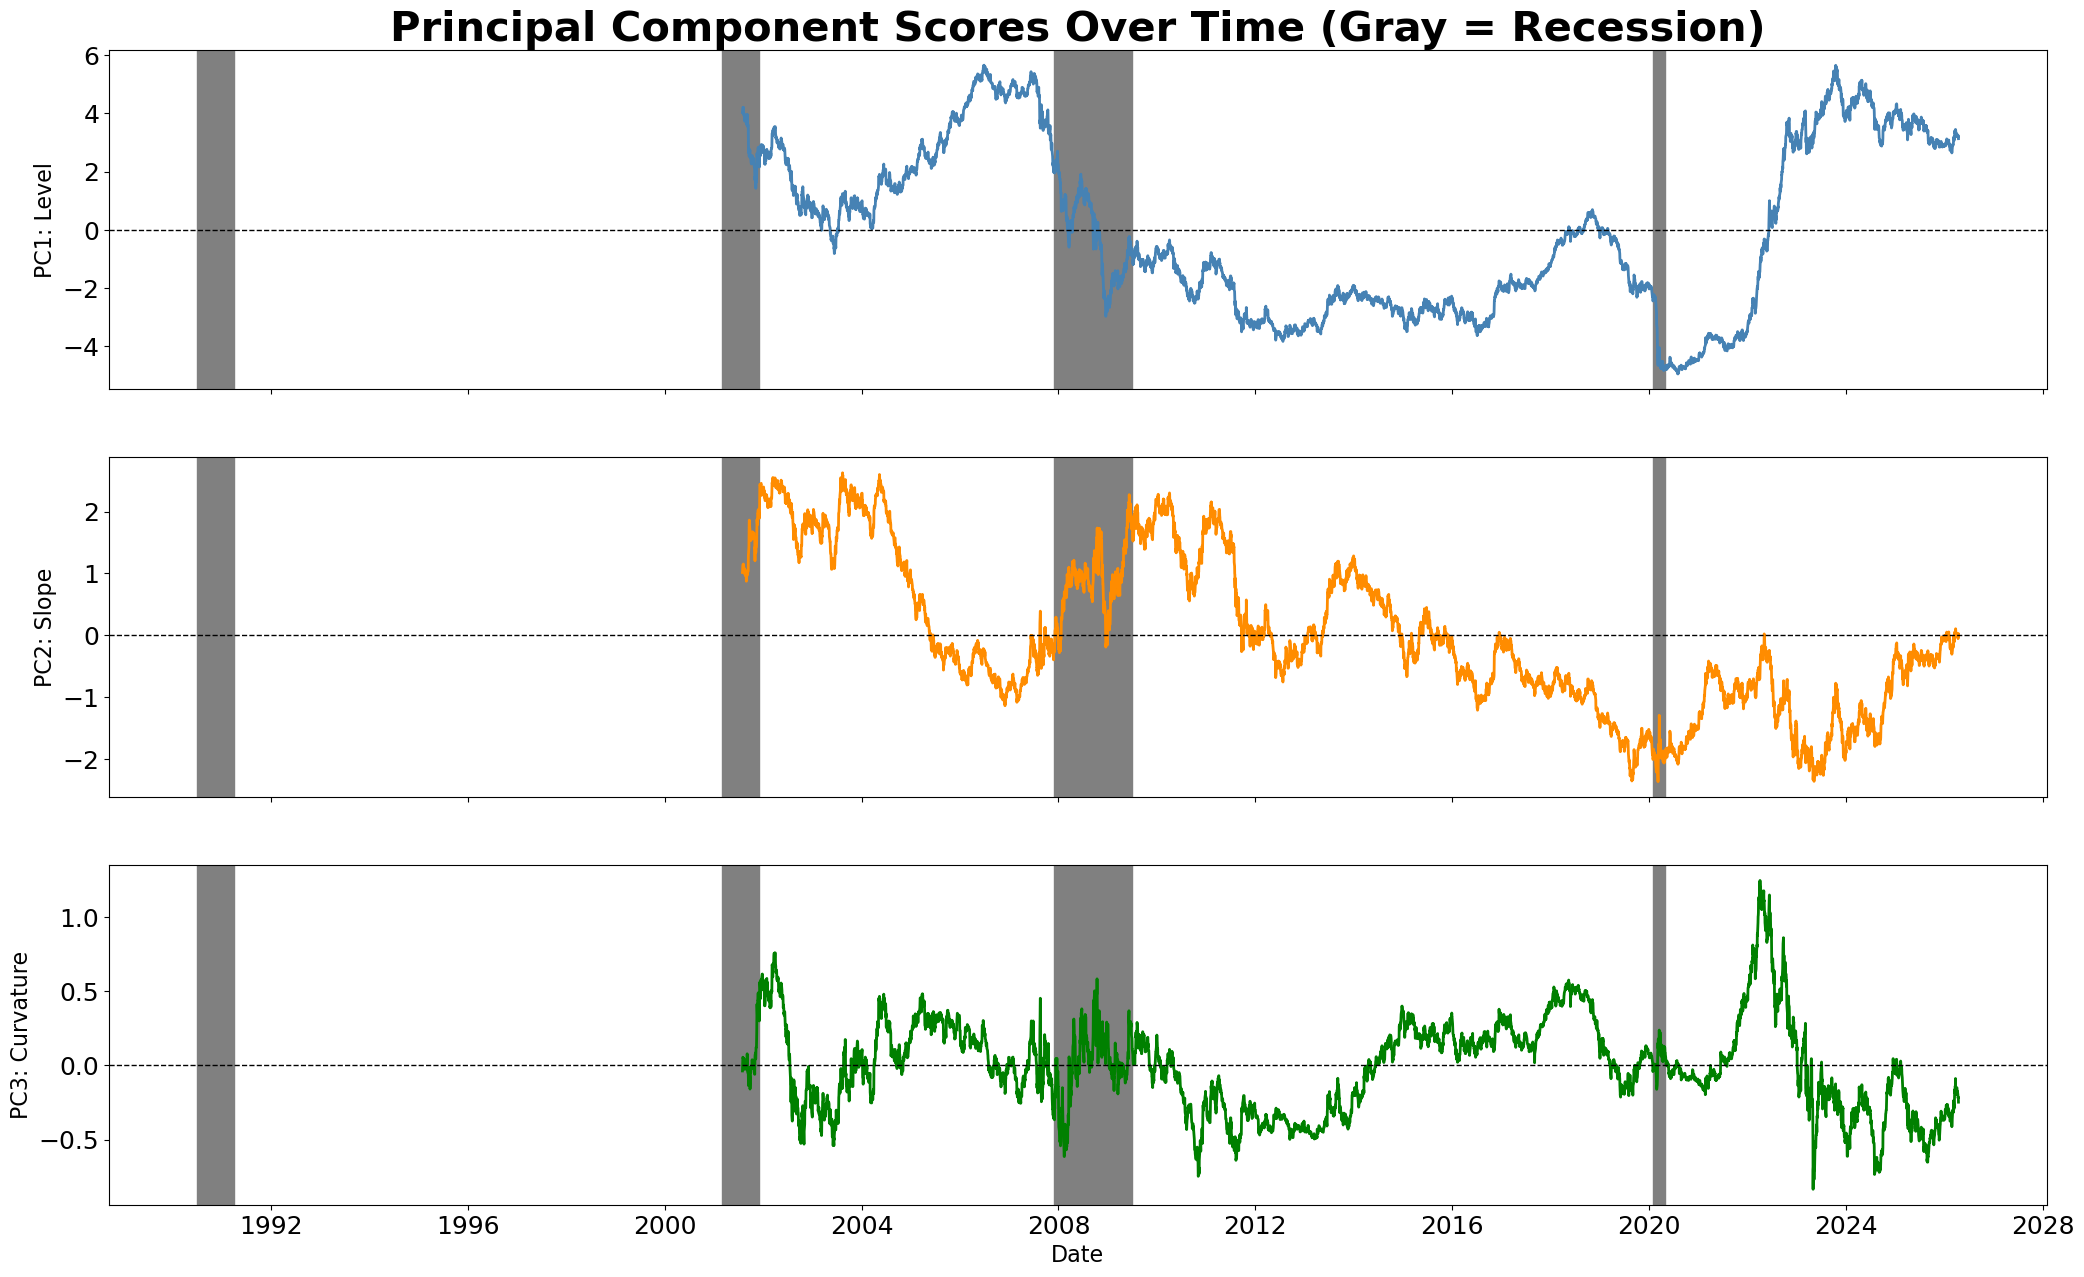

In [ ]:
def plot_pc_scores(scores_df):
    recessions = [
        ('1990-07-01', '1991-03-31'),
        ('2001-03-01', '2001-11-30'),
        ('2007-12-01', '2009-06-30'),
        ('2020-02-01', '2020-04-30'),
    ]
    
    pc_labels = ['PC1: Level', 'PC2: Slope', 'PC3: Curvature']
    pc_colors = ['steelblue', 'darkorange', 'green']
    
    fig, axes = plt.subplots(3, 1, figsize=(25, 15), sharex=True)
    
    for i, (ax, label, color) in enumerate(zip(axes, pc_labels, pc_colors)):
        col = f'PC{i+1}'
        ax.plot(scores_df.index, scores_df[col], linewidth=2, color=color)
        ax.axhline(0, color='black', linewidth=1, linestyle='--')
        ax.set_ylabel(label, fontsize=16)
        ax.tick_params(axis='both', labelsize=18)
        
        for start, end in recessions:
            ax.axvspan(pd.Timestamp(start), pd.Timestamp(end), color='gray')
    
    
    axes[0].set_title('Principal Component Scores Over Time', fontsize=30, fontweight='bold')
    axes[-1].set_xlabel('Date', fontsize=16)
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.savefig('pc_over_time.png', dpi=150)
    plt.show()


plot_pc_scores(pc_scores)